In [1]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for our charts
sns.set_theme(style="whitegrid")
print("Libraries successfully loaded!")

Libraries successfully loaded!


In [2]:
# Cell 2
# Load the data we saved at the end of the previous notebook
file_path = "../data/clean_cervical_cancer_data.csv"
df = pd.read_csv(file_path)

print(f"Data loaded! Shape: {df.shape[0]} patients and {df.shape[1]} features.")
df.head()

Data loaded! Shape: 858 patients and 34 features.


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0.0,0,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0


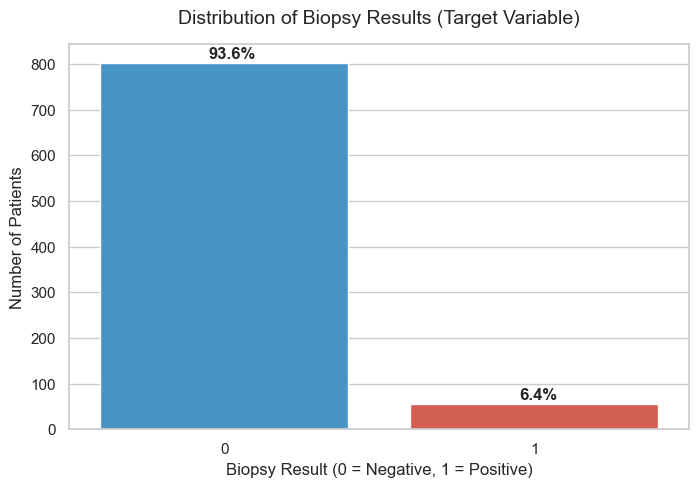

In [3]:
# Cell 3
plt.figure(figsize=(8, 5))

# Plot the count of positive vs negative biopsies
# FIX: Added hue='Biopsy' and legend=False to resolve the FutureWarning
ax = sns.countplot(
    data=df, 
    x='Biopsy', 
    hue='Biopsy', 
    palette=['#3498db', '#e74c3c'], 
    legend=False
)

plt.title("Distribution of Biopsy Results (Target Variable)", fontsize=14, pad=15)
plt.xlabel("Biopsy Result (0 = Negative, 1 = Positive)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Add percentage labels on top of the bars for clarity
total_patients = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_patients:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 10
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.show()

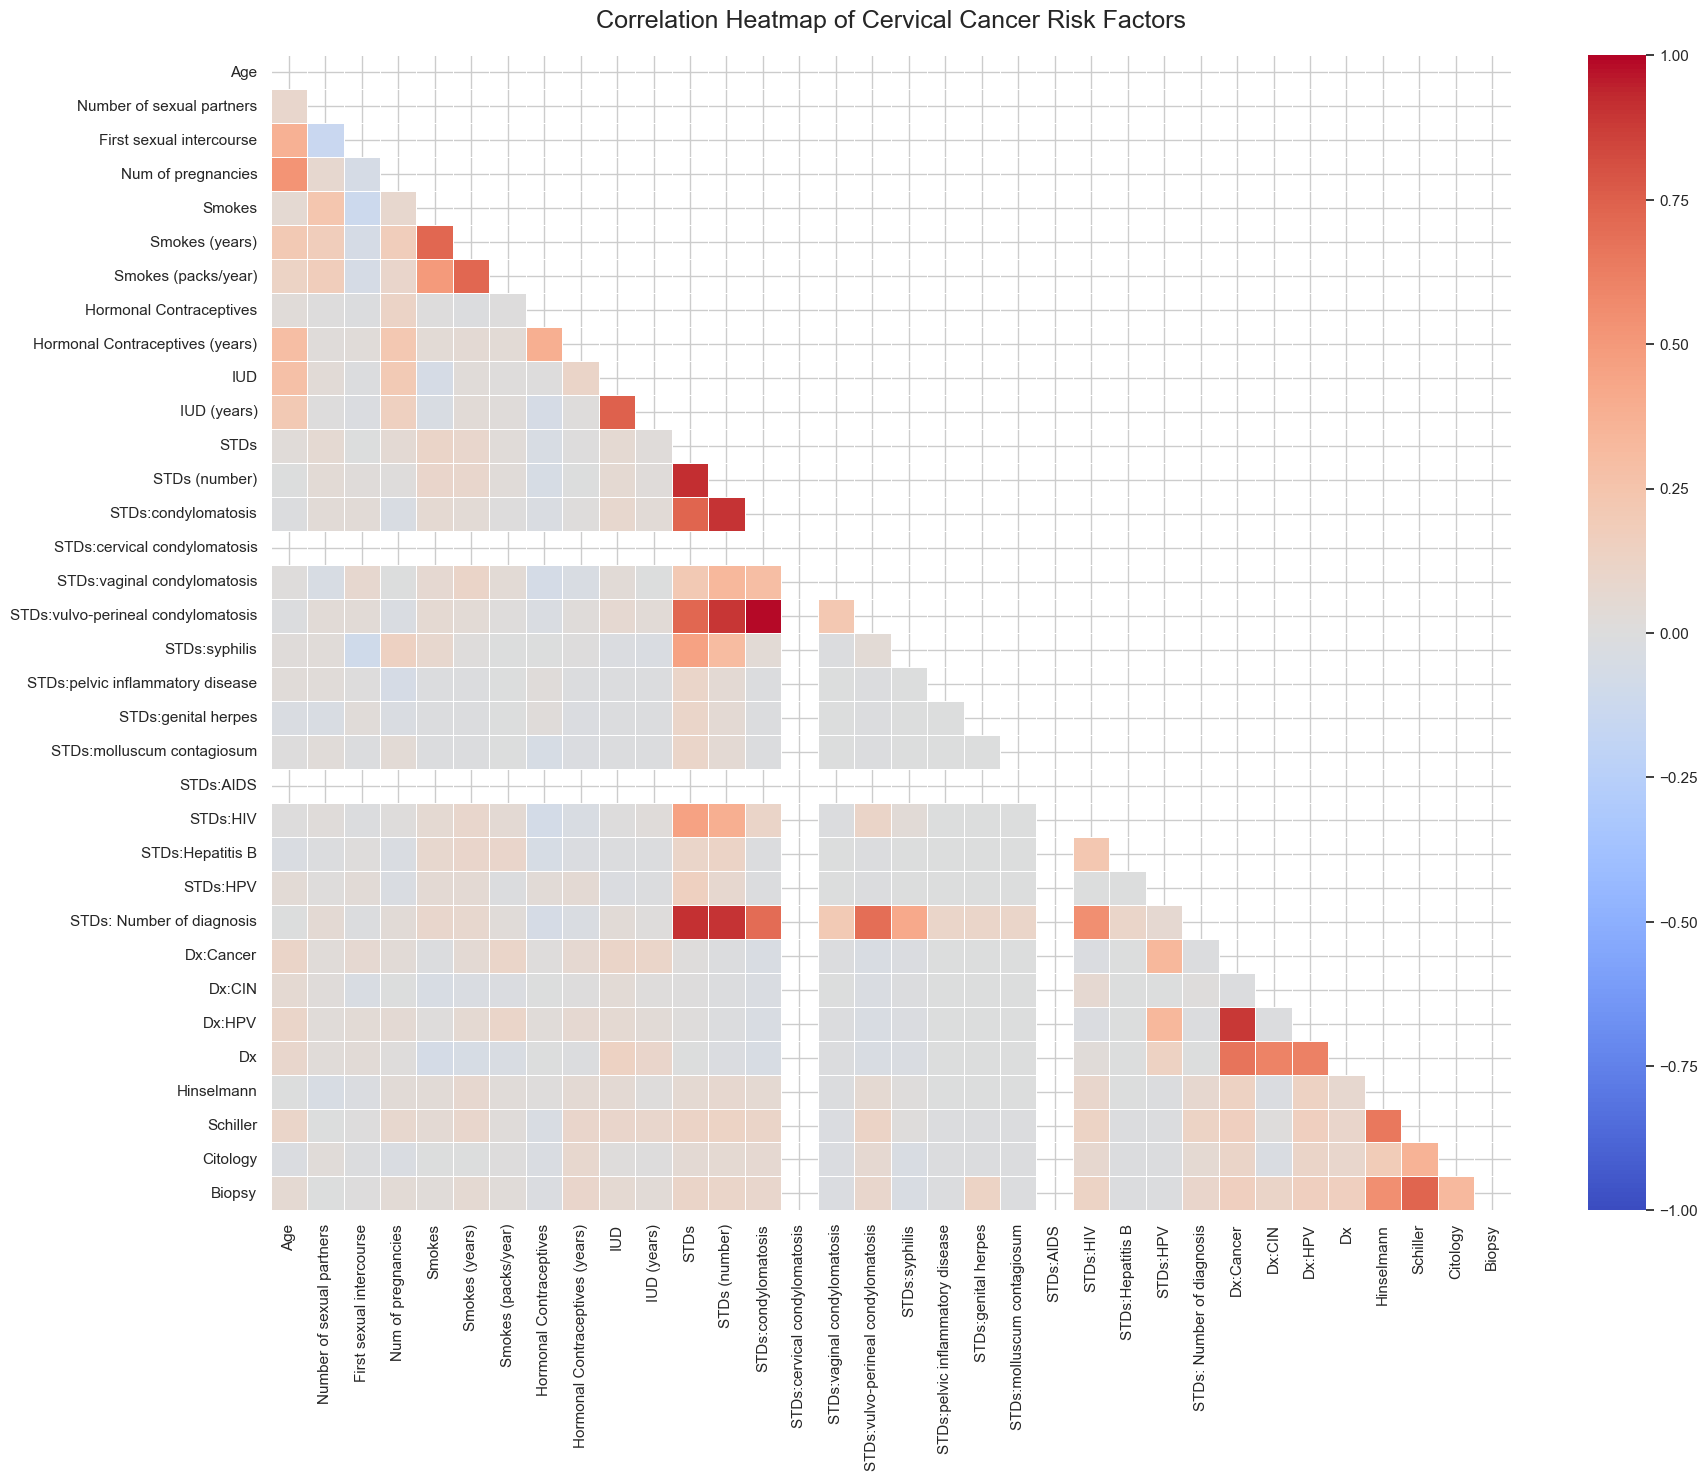

In [4]:
# Cell 4
plt.figure(figsize=(20, 15))

# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a mask to hide the upper triangle (prevents duplicate visual info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=False, # Set to True if you want the exact numbers, but it gets crowded!
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0, 
            linewidths=0.5)

plt.title("Correlation Heatmap of Cervical Cancer Risk Factors", fontsize=18, pad=20)
plt.show()

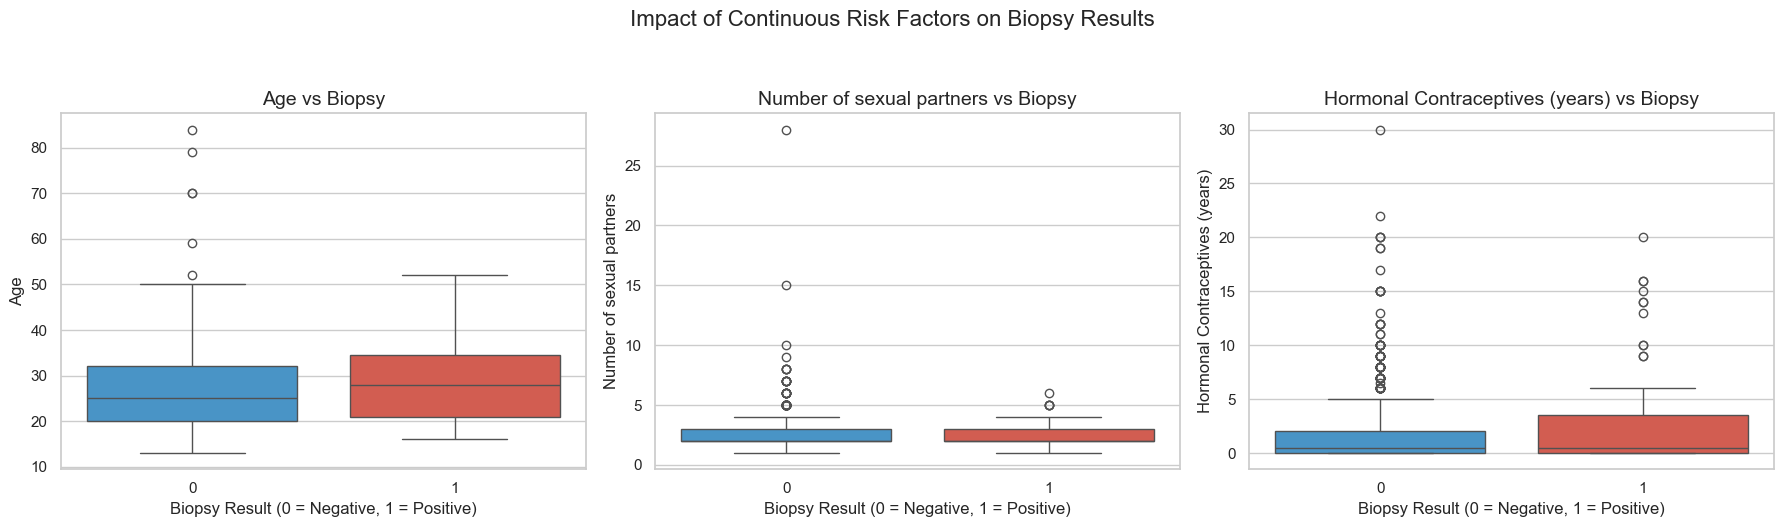

In [5]:
# %%
# Cell 5
# 1. Define the continuous features we want to investigate
continuous_features = ['Age', 'Number of sexual partners', 'Hormonal Contraceptives (years)']

# 2. Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of Continuous Risk Factors on Biopsy Results', fontsize=16, y=1.05)

# 3. Loop through the features and draw a boxplot for each
for i, feature in enumerate(continuous_features):
    # FIX: Added hue='Biopsy' and legend=False
    sns.boxplot(ax=axes[i], data=df, x='Biopsy', y=feature, hue='Biopsy', palette=['#3498db', '#e74c3c'], legend=False)
    
    # Clean up the labels for presentations
    axes[i].set_title(f'{feature} vs Biopsy', fontsize=14)
    axes[i].set_xlabel('Biopsy Result (0 = Negative, 1 = Positive)', fontsize=12)
    axes[i].set_ylabel(feature, fontsize=12)

plt.tight_layout()
plt.show()

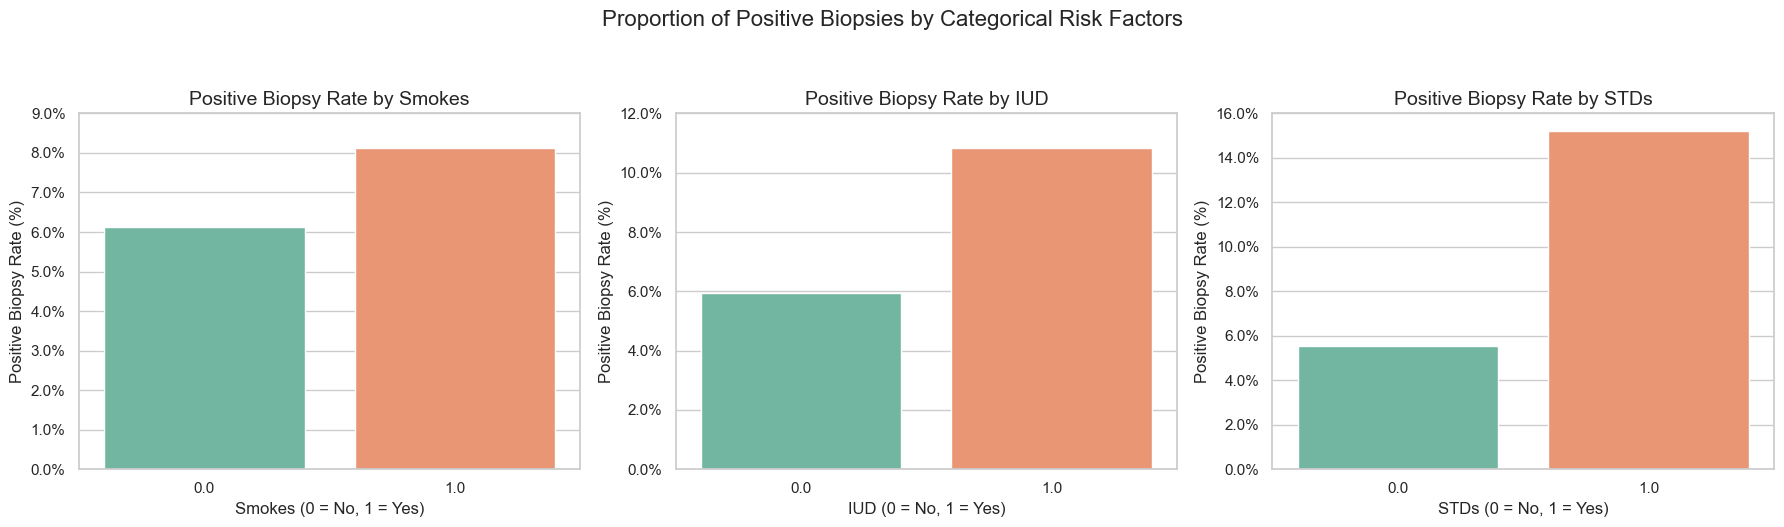

In [6]:
# %%
# Cell 6
# 1. Define the categorical lifestyle/medical history features
categorical_features = ['Smokes', 'IUD', 'STDs']

# 2. Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Proportion of Positive Biopsies by Categorical Risk Factors', fontsize=16, y=1.05)

# 3. Loop through features and plot the positive rate
for i, feature in enumerate(categorical_features):
    # FIX: Added hue=feature and legend=False
    sns.barplot(ax=axes[i], data=df, x=feature, y='Biopsy', hue=feature, palette='Set2', errorbar=None, legend=False)
    
    axes[i].set_title(f'Positive Biopsy Rate by {feature}', fontsize=14)
    axes[i].set_xlabel(f'{feature} (0 = No, 1 = Yes)', fontsize=12)
    axes[i].set_ylabel('Positive Biopsy Rate (%)', fontsize=12)
    
    # Format the y-axis to show percentages
    ticks = axes[i].get_yticks()
    axes[i].set_yticks(ticks)  # FIX: Explicitly set ticks before setting labels
    axes[i].set_yticklabels([f'{tick * 100:.1f}%' for tick in ticks])

plt.tight_layout()
plt.show()

In [7]:
# Cell 7
print("--- 1. Removing Zero-Variance Columns ---")
# Find columns where there is only 1 unique value (zero variance)
zero_var_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Zero-variance columns found and dropped: {zero_var_cols}\n")

# Drop them temporarily to calculate the correlation matrix safely
df_temp = df.drop(columns=zero_var_cols)

print("--- 2. Identifying Highly Correlated Pairs ---")
# Calculate the absolute correlation matrix
corr_matrix = df_temp.corr().abs()

# Keep only the upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Set your threshold
threshold = 0.85

# Stack the matrix to create a simple list of (Row, Column) -> Value
stacked = upper.stack()

# Filter only the pairs that exceed the threshold
high_corr_pairs = stacked[stacked > threshold]

print(f"Found {len(high_corr_pairs)} highly correlated pairs (Threshold > {threshold}):\n")

# Loop through and print them beautifully so you can decide
for index, value in high_corr_pairs.items():
    feature_A, feature_B = index
    print(f"- {feature_A}  <--->  {feature_B}  (Correlation: {value:.2f})")

--- 1. Removing Zero-Variance Columns ---
Zero-variance columns found and dropped: ['STDs:cervical condylomatosis', 'STDs:AIDS']

--- 2. Identifying Highly Correlated Pairs ---
Found 7 highly correlated pairs (Threshold > 0.85):

- STDs  <--->  STDs (number)  (Correlation: 0.92)
- STDs  <--->  STDs: Number of diagnosis  (Correlation: 0.91)
- STDs (number)  <--->  STDs:condylomatosis  (Correlation: 0.90)
- STDs (number)  <--->  STDs:vulvo-perineal condylomatosis  (Correlation: 0.89)
- STDs (number)  <--->  STDs: Number of diagnosis  (Correlation: 0.90)
- STDs:condylomatosis  <--->  STDs:vulvo-perineal condylomatosis  (Correlation: 0.99)
- Dx:Cancer  <--->  Dx:HPV  (Correlation: 0.89)


In [8]:
# Cell 8
print("--- Outlier Detection Report (IQR Method) ---")

# We only check continuous variables for outliers, not binary (0/1) ones
continuous_cols = ['Age', 'Number of sexual partners', 'First sexual intercourse', 
                   'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)']

for col in continuous_cols:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds for what is considered an "outlier"
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many patients fall outside these bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    
    if outlier_count > 0:
        print(f"{col}: {outlier_count} outliers detected ({(outlier_count/len(df))*100:.1f}% of data)")
        # Uncomment the line below if you want to see the exact outlier numbers
        # print(f"    Values: {outliers[col].unique()}")

--- Outlier Detection Report (IQR Method) ---
Age: 8 outliers detected (0.9% of data)
Number of sexual partners: 68 outliers detected (7.9% of data)
First sexual intercourse: 41 outliers detected (4.8% of data)
Num of pregnancies: 10 outliers detected (1.2% of data)
Smokes (years): 123 outliers detected (14.3% of data)
Hormonal Contraceptives (years): 114 outliers detected (13.3% of data)


In [9]:
# Cell 9
from scipy import stats

print("==================================================")
print("STATISTICAL SIGNIFICANCE REPORT (Target: Biopsy)")
print("==================================================\n")

# 1. Define our threshold for significance (Standard is 5%)
alpha = 0.05
significant_features = []

# 2. Dynamically separate remaining columns into continuous and categorical
# We assume anything with > 10 unique values is continuous, else categorical
continuous_cols = [col for col in df.columns if df[col].nunique() > 10 and col != 'Biopsy']
categorical_cols = [col for col in df.columns if df[col].nunique() <= 10 and col != 'Biopsy']

print("--- 1. Continuous Features (Welch's t-test) ---")
for col in continuous_cols:
    # Split the data into two groups based on Biopsy result
    group_positive = df[df['Biopsy'] == 1][col]
    group_negative = df[df['Biopsy'] == 0][col]
    
    # Run Welch's t-test (equal_var=False)
    t_stat, p_value = stats.ttest_ind(group_positive, group_negative, equal_var=False)
    
    if p_value < alpha:
        print(f"[SIGNIFICANT] {col}: p-value = {p_value:.4f}")
        significant_features.append(col)
    else:
        # We can print the non-significant ones too, or keep it quiet
        pass 

print("\n--- 2. Categorical Features (Chi-Square Test) ---")
for col in categorical_cols:
    # Create a contingency table (cross-tabulation)
    contingency_table = pd.crosstab(df[col], df['Biopsy'])
    
    # Run the Chi-Square test
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    if p_value < alpha:
        print(f"[SIGNIFICANT] {col}: p-value = {p_value:.4f}")
        significant_features.append(col)

print("\n==================================================")
print(f"Total Statistically Significant Features: {len(significant_features)}")
print("These are the strongest candidates for our Machine Learning model.")
print("==================================================")

STATISTICAL SIGNIFICANCE REPORT (Target: Biopsy)

--- 1. Continuous Features (Welch's t-test) ---

--- 2. Categorical Features (Chi-Square Test) ---
[SIGNIFICANT] STDs: p-value = 0.0019
[SIGNIFICANT] STDs (number): p-value = 0.0201
[SIGNIFICANT] STDs:condylomatosis: p-value = 0.0201
[SIGNIFICANT] STDs:vulvo-perineal condylomatosis: p-value = 0.0168
[SIGNIFICANT] STDs:HIV: p-value = 0.0011
[SIGNIFICANT] STDs: Number of diagnosis: p-value = 0.0077
[SIGNIFICANT] Dx:Cancer: p-value = 0.0000
[SIGNIFICANT] Dx:CIN: p-value = 0.0085
[SIGNIFICANT] Dx:HPV: p-value = 0.0000
[SIGNIFICANT] Dx: p-value = 0.0000
[SIGNIFICANT] Hinselmann: p-value = 0.0000
[SIGNIFICANT] Schiller: p-value = 0.0000
[SIGNIFICANT] Citology: p-value = 0.0000

Total Statistically Significant Features: 13
These are the strongest candidates for our Machine Learning model.
